In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
    
import os
from dotenv import load_dotenv
from datetime import datetime, timedelta, timezone
from prometheus_api_client import PrometheusConnect
os.environ.setdefault("DARTS_CONFIGURE_MATPLOTLIB", "0")
from darts.models import RNNModel
from darts.metrics import mape, mae, rmse
from darts.dataprocessing.transformers import Scaler
from darts import TimeSeries    

from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from pytorch_lightning.callbacks import LearningRateMonitor
from torch.optim.lr_scheduler import StepLR
import torch
device = torch.device("cpu") # force CPU usage

/Users/AlicePiemonti/miniconda3/envs/darts/lib/python3.12/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore


In [2]:
# -------- Device Detection --------
if torch.backends.mps.is_available():
    device = torch.device("mps")
    force_float32 = True
elif torch.cuda.is_available():
    device = torch.device("cuda")
    force_float32 = False
else:
    device = torch.device("cpu")
    force_float32 = False

print(f"Using device: {device}, force_float32={force_float32}")

Using device: mps, force_float32=True


In [3]:
load_dotenv(dotenv_path='../src/.env')

DB_NAME=os.getenv('DB_NAME')
DB_USER=os.getenv('DB_USER')
DB_PASSWORD=os.getenv('DB_SECRET')
DB_HOST=os.getenv('DB_HOSTNAME')
DB_PORT=os.getenv('DB_PORT')
PROMETHEUS_HOSTNAME = 'metrics.6g-ntn.eu/prometheus'
METRIC = "container_cpu_usage_seconds_total" 
#METRIC = "container_memory_usage_bytes"

In [9]:
# Connecting to a remote instance of Prometheus
prom = PrometheusConnect(url=F'http://{PROMETHEUS_HOSTNAME}', disable_ssl=True)

# extracting data from Prometheus: for node 1 and container upf1
query =  (f'sum by(pod, namespace)(rate({METRIC}{{namespace="open5gs", node="6g-ntn-f5gc-w2", pod=~"upf2-open5gs-upf-.*"}}[1m]))') 
end_time = datetime.now(timezone.utc)
start_time = end_time - timedelta(minutes=7455) # about 5 days
step = '5m'

result = prom.custom_query_range(query=query, start_time=start_time, end_time=end_time, step=step)
df = pd.DataFrame(result[0]['values'], columns=['timestamp', 'value'])

if force_float32:
    df = df.astype(np.float32)
df

/Users/AlicePiemonti/miniconda3/envs/darts/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'metrics.6g-ntn.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


,timestamp,value
0,1.763286e+09,0.000108
1,1.763287e+09,0.000114
2,1.763287e+09,0.000100
3,1.763287e+09,0.000100
4,1.763287e+09,0.000105
...,...,...
1487,1.763732e+09,0.000112
1488,1.763733e+09,0.000123
1489,1.763733e+09,0.000138
1490,1.763733e+09,0.000103


(array([20408.41666667, 20408.45833333, 20408.5       , 20408.54166667,
        20408.58333333, 20408.625     , 20408.66666667, 20408.70833333,
        20408.75      ]),
 [Text(20408.416666666668, 0, '11-16 10'),
  Text(20408.458333333332, 0, '11-16 11'),
  Text(20408.5, 0, '11-16 12'),
  Text(20408.541666666668, 0, '11-16 13'),
  Text(20408.583333333332, 0, '11-16 14'),
  Text(20408.625, 0, '11-16 15'),
  Text(20408.666666666668, 0, '11-16 16'),
  Text(20408.708333333332, 0, '11-16 17'),
  Text(20408.75, 0, '11-16 18')])

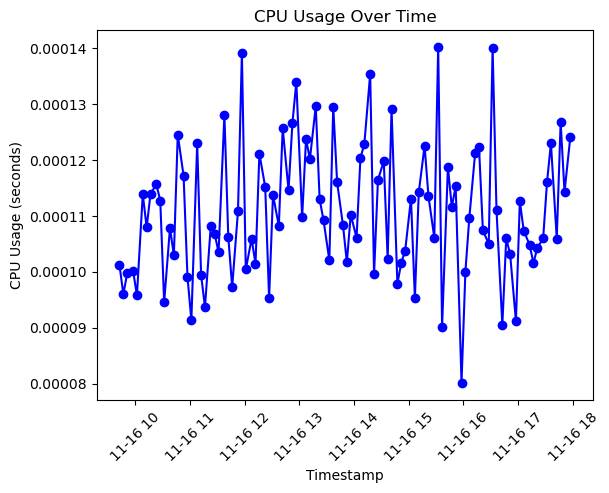

In [7]:
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')
df['value'] = pd.to_numeric(df['value'])
plt.plot(df['timestamp'][:100], df['value'][:100], marker='o', linestyle='-', color='b') # Plotting the first 100 data points
plt.xlabel('Timestamp')
plt.ylabel('CPU Usage (seconds)')
plt.title('CPU Usage Over Time')
#print(f"Delta minutes: {delta_min} or days: {round(delta_min/60/24)}\nStep: {step}")
# rotate x labels for better readability
plt.xticks(rotation=45)

Starting data analysis from csv

In [124]:
# #df = pd.read_csv("./../datasets/Benchmarking on Microservices Configurations and the Impact on the Performance in Cloud Native Environments/amf-performance.csv")
# df['datetime'] = pd.to_datetime(df['timestamp'], unit='s') # resample function needs a datetime column
# #df = df.drop(['time', 'lat75', 'lat80', 'lat90', 'lat95', 'lat98', 'lat99', 'lat100'], axis=1)

frequency = '5T' # 5 minutes frequency

# # additional features
#df['day'] = pd.DatetimeIndex(df['datetime']).day
#df['hour'] = pd.DatetimeIndex(df['datetime']).hour

# # Remove from ram_limit 'M' and convert the column to integer
# #df['ram_limit'] = df['ram_limit'].str.replace('M', '').astype(int)

df_resampled = df.resample(frequency, on='timestamp').max()
df_resampled

/var/folders/vr/sg92rdxs1cq_7f1s1jhpw2dh0000gn/T/ipykernel_83089/2306709190.py:14: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_resampled = df.resample(frequency, on='timestamp').max()


,value
timestamp,
2025-08-27 09:40:00,0.00000
2025-08-27 09:45:00,NaN
2025-08-27 09:50:00,0.00000
2025-08-27 09:55:00,0.00000
2025-08-27 10:00:00,NaN
...,...
2025-09-01 13:30:00,0.00011
2025-09-01 13:35:00,0.00013
2025-09-01 13:40:00,NaN


In [116]:
# f, ax = plt.subplots(nrows=1, ncols=1, figsize=(16,5))

# sns.heatmap(df_max.iloc[:,2:-1].T.isna(), cmap='Blues') #drop useless columns
# ax.set_title('Missing Values', fontsize=16)

# # Rotate y-axis labels
# ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # Set the rotation angle as needed


# for tick in ax.yaxis.get_major_ticks():
#     tick.label1.set_fontsize(14)
# plt.show()

Remove the big portion of missing values

In [117]:
# # Set the filter condition based on the desired date and time
# df_max_reset = df_max.reset_index()
# df_max_reset['datetime'] = pd.to_datetime(df_max_reset['datetime'])
# filter_condition = df_max_reset['datetime'] > '2021-11-12 14:00:00'

# # Apply the filter to get the subset of the DataFrame
# filtered_df = df_max_reset[filter_condition].set_index('datetime')

Plot filtered datafarame

In [118]:
# f, ax = plt.subplots(nrows=1, ncols=1, figsize=(16,5))

# sns.heatmap(filtered_df.iloc[:,2:-1].T.isna(), cmap='Blues') #drop useless columns
# ax.set_title('Missing Values', fontsize=16)

# # Rotate y-axis labels
# ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # Set the rotation angle as needed


# for tick in ax.yaxis.get_major_ticks():
#     tick.label1.set_fontsize(14)
# plt.show()

Interpolate in order to fill the null values in the df

In [ ]:
interpolated_df = df_resampled.interpolate()
interpolated_df.isna().sum()

timestamp    0
value        0
dtype: int64

In [11]:
interpolated_df.reset_index(inplace=True)
interpolated_df["cpu_usage"] = interpolated_df["value"]
interpolated_df["datetime"] = pd.to_datetime(interpolated_df["timestamp"])
interpolated_df = interpolated_df.drop(columns=["value", "timestamp"])
interpolated_df

,index,cpu_usage,datetime
0,0,0.000108,1970-01-01 00:00:01.763286272
1,1,0.000114,1970-01-01 00:00:01.763286528
2,2,0.000100,1970-01-01 00:00:01.763286784
3,3,0.000100,1970-01-01 00:00:01.763287168
4,4,0.000105,1970-01-01 00:00:01.763287424
...,...,...,...
1487,1487,0.000112,1970-01-01 00:00:01.763732352
1488,1488,0.000123,1970-01-01 00:00:01.763732608
1489,1489,0.000138,1970-01-01 00:00:01.763732864
1490,1490,0.000103,1970-01-01 00:00:01.763733248


# LSTM univariate forecasting
Forecast one time series. Possible time series are: 'cpu_usage', 'ram_usage', 'cpu_limit', 'ram_limit'

In [12]:
# define train and test size
train_size = int(0.7 * len(interpolated_df))
test_size = len(interpolated_df) - train_size

split_point = interpolated_df.iloc[train_size].name
split_point

1044

define TimeSeries components and train a LSTM with the target component

In [ ]:
series = TimeSeries.from_dataframe(interpolated_df.reset_index(), 'datetime', ['cpu_usage'])

# train test split
train, test = series.split_after(split_point)

# Normalize the time series (note: we avoid fitting the transformer on the validation set)
transformer = Scaler()
train_transformed = transformer.fit_transform(train)
val_transformed = transformer.transform(test)
series_transformed = transformer.transform(series)

/Users/AlicePiemonti/miniconda3/envs/darts/lib/python3.12/site-packages/darts/timeseries.py:4804: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  resampled_time_index = resampled_time_index.asfreq(freq)
ValueError: Could not correctly fill missing dates with the observed/passed frequency `freq='5T'`. Not all input time stamps contained in the newly created TimeSeries. For more information about frequency aliases, read https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases


ValueError: Could not correctly fill missing dates with the observed/passed frequency `freq='5T'`. Not all input time stamps contained in the newly created TimeSeries. For more information about frequency aliases, read https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases

In [131]:
# define early stopping parameters
my_stopper = EarlyStopping(
    monitor="val_loss",
    patience=20,
    min_delta=0.0005,
    mode='min',
)

# Define learning rate scheduler
lr_scheduler_config = {
    "scheduler": StepLR,  # Example: StepLR decreases LR by a factor every few epochs
    "step_size": 20,      # Decrease LR every 25 epochs
    "gamma": 0.1,         # LR decay factor
}

# Define learning rate monitor callback (optional but useful for visualization)
lr_monitor = LearningRateMonitor(logging_interval='epoch')

pl_trainer_kwargs={"callbacks": [my_stopper], "log_every_n_steps": 5}

# build model
my_model = RNNModel(
    model="LSTM",
    hidden_dim=20,
    dropout=0,
    batch_size=8,
    n_epochs=100,
    optimizer_kwargs={"lr": 1e-2},
    model_name="LSTM_forecast_univariate",
    log_tensorboard=True,
    random_state=42,
    training_length=20,
    input_chunk_length=5,
    force_reset=True,
    save_checkpoints=True,
    pl_trainer_kwargs=pl_trainer_kwargs,
    lr_scheduler_cls=lr_scheduler_config["scheduler"],
    lr_scheduler_kwargs={
        "step_size": lr_scheduler_config["step_size"],
        "gamma": lr_scheduler_config["gamma"]
    }
)

# train model
my_model.fit(
    train_transformed,
    val_series=val_transformed,
    verbose=True,
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 1.8 K  | train
6 | V               | Linear           | 21     | train
-------------------------------------------------------------
1.9 K     Trainable params
0         Non-trainable params
1.9 K     Total params
0.007     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

/Users/AlicePiemonti/miniconda3/envs/darts/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Training: |                                               | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

...

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

RNNModel(model=LSTM, hidden_dim=20, n_rnn_layers=1, dropout=0, training_length=20, batch_size=8, n_epochs=100, optimizer_kwargs={'lr': 0.01}, model_name=LSTM_forecast_univariate, log_tensorboard=True, random_state=42, input_chunk_length=5, force_reset=True, save_checkpoints=True, pl_trainer_kwargs={'callbacks': [<pytorch_lightning.callbacks.early_stopping.EarlyStopping object at 0x30523a570>], 'log_every_n_steps': 5}, lr_scheduler_cls=<class 'torch.optim.lr_scheduler.StepLR'>, lr_scheduler_kwargs={'step_size': 20, 'gamma': 0.1})

In [132]:
best_model = RNNModel.load_from_checkpoint(model_name="LSTM_forecast_univariate", best=True)

pred_series = best_model.historical_forecasts(
    series_transformed[train_size- my_model.input_chunk_length + 1:],
    start = val_transformed.time_index[0],
    forecast_horizon=1,
    stride=1,
    retrain=False,
    last_points_only=True,
    verbose=True,
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/AlicePiemonti/miniconda3/envs/darts/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Predicting: |                                             | 0/? [00:00<?, ?it/s]

In [133]:
len(pred_series)

447

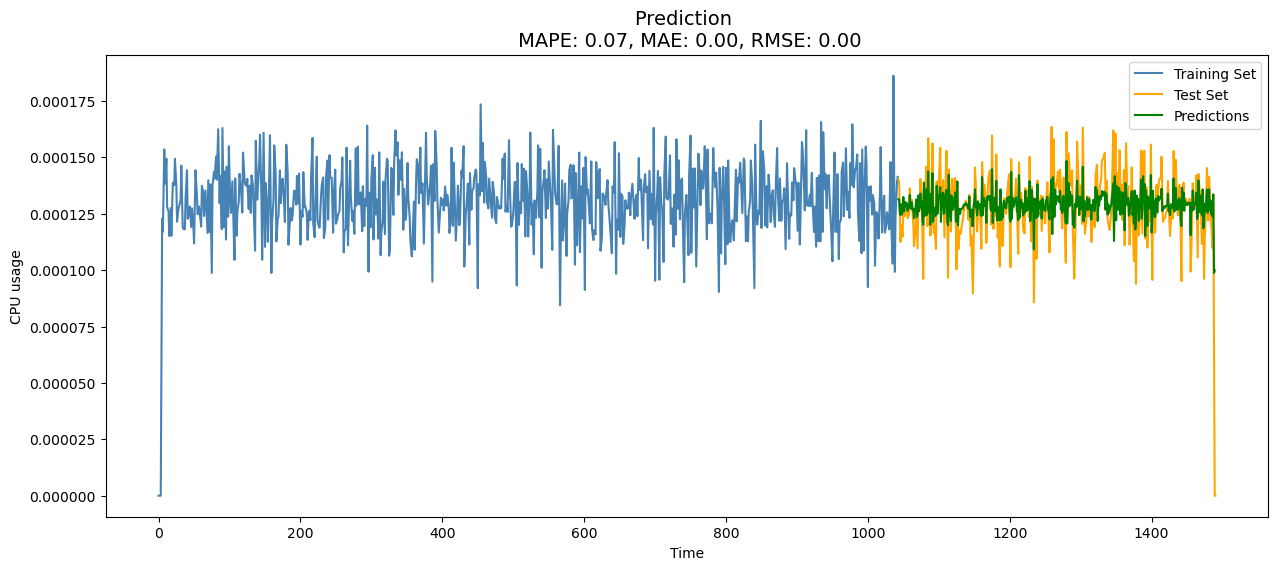

In [134]:
# Plot the forecast
f, ax = plt.subplots(1)
f.set_figheight(6)
f.set_figwidth(15)

pred_series_inverse = transformer.inverse_transform(pred_series)


mape_score = mape(pred_series_inverse, test)/100
mae_score = mae(pred_series_inverse, test)
rmse_score = rmse(pred_series_inverse, test)

pred_series_ravel = pred_series_inverse.values().ravel()

# Plot the data
ax.plot(interpolated_df.index[:train_size], series[:train_size].values(), label="Training Set", color="steelblue")
ax.plot(interpolated_df.index[train_size:], series[train_size:].values(), label="Test Set", color="orange")
ax.plot(interpolated_df.index[train_size:-1], pred_series_ravel, label="Predictions", color='green')
plt.title(f'Prediction \n MAPE: {mape_score:.2f}, MAE: {mae_score:.2f}, RMSE: {rmse_score:.2f}', fontsize=14)

plt.xlabel('Time')
plt.ylabel('CPU usage') 
plt.legend()

plt.show()